Maximizing Revenue For Taxi Cab Drivers Through Payment Type Analysis :

Problem Statement :
In the fast-paced taxi booking sector, making the most of revenue is essential for long-term success and driver happiness. Our goal is to use data-driven insights to
maximise revenue streams for taxi drivers in order to meet this need. Our research aims to determine whether payment methods have an impact on fare pricing by focusing on the relationship between payment type and fare amount.

Objective :
This project main goal is to run an A/b test to examine the relationship between the total fair and the method of payment.We use python hypothesis testing and description statics to extract useful information that can help taxi drivers generate more cash. I n particular , we want to find out if there is a big difference in the fares for those who pay with credit card versus those who pay with cash.

Reasearch question :
Is there is relationship between total fare amount and payemnt type and can we nudge customers towards payemnt methods that generate higher revenue for drivers, without negatively impacting customers experience.


In [109]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
import statsmodels.api as sm
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [110]:
df = pd.read_csv('/content/yellow_tripdata_2021-01.csv.gz')

In [111]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
0,1.0,2021-01-01 00:30:10,2021-01-01 00:36:12,1.0,2.10,1.0,N,142,43,2.0,8.0,3.0,0.5,0.00,0.0,0.3,11.80,2.5
1,1.0,2021-01-01 00:51:20,2021-01-01 00:52:19,1.0,0.20,1.0,N,238,151,2.0,3.0,0.5,0.5,0.00,0.0,0.3,4.30,0.0
2,1.0,2021-01-01 00:43:30,2021-01-01 01:11:06,1.0,14.70,1.0,N,132,165,1.0,42.0,0.5,0.5,8.65,0.0,0.3,51.95,0.0
3,1.0,2021-01-01 00:15:48,2021-01-01 00:31:01,0.0,10.60,1.0,N,138,132,1.0,29.0,0.5,0.5,6.05,0.0,0.3,36.35,0.0
4,2.0,2021-01-01 00:31:49,2021-01-01 00:48:21,1.0,4.94,1.0,N,68,33,1.0,16.5,0.5,0.5,4.06,0.0,0.3,24.36,2.5


Exploratory Data Analysis

In [112]:
df.shape

(1369765, 18)

In [113]:
df.dtypes

,0
VendorID,float64
tpep_pickup_datetime,object
tpep_dropoff_datetime,object
passenger_count,float64
trip_distance,float64
RatecodeID,float64
store_and_fwd_flag,object
PULocationID,int64
DOLocationID,int64
payment_type,float64


In [114]:
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

In [115]:
df.dtypes

,0
VendorID,float64
tpep_pickup_datetime,datetime64[ns]
tpep_dropoff_datetime,datetime64[ns]
passenger_count,float64
trip_distance,float64
RatecodeID,float64
store_and_fwd_flag,object
PULocationID,int64
DOLocationID,int64
payment_type,float64


In [116]:
df['duration']=df['tpep_dropoff_datetime']-df['tpep_pickup_datetime']
df['duration']=df['duration'].dt.total_seconds()/60
df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,duration
0,1.0,2021-01-01 00:30:10,2021-01-01 00:36:12,1.0,2.10,1.0,N,142,43,2.0,8.00,3.00,0.5,0.00,0.0,0.3,11.80,2.5,6.033333
1,1.0,2021-01-01 00:51:20,2021-01-01 00:52:19,1.0,0.20,1.0,N,238,151,2.0,3.00,0.50,0.5,0.00,0.0,0.3,4.30,0.0,0.983333
2,1.0,2021-01-01 00:43:30,2021-01-01 01:11:06,1.0,14.70,1.0,N,132,165,1.0,42.00,0.50,0.5,8.65,0.0,0.3,51.95,0.0,27.600000
3,1.0,2021-01-01 00:15:48,2021-01-01 00:31:01,0.0,10.60,1.0,N,138,132,1.0,29.00,0.50,0.5,6.05,0.0,0.3,36.35,0.0,15.216667
4,2.0,2021-01-01 00:31:49,2021-01-01 00:48:21,1.0,4.94,1.0,N,68,33,1.0,16.50,0.50,0.5,4.06,0.0,0.3,24.36,2.5,16.533333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1369760,NaN,2021-01-25 08:32:04,2021-01-25 08:49:32,NaN,8.80,NaN,NaN,135,82,NaN,21.84,2.75,0.5,0.00,0.0,0.3,25.39,0.0,17.466667
1369761,NaN,2021-01-25 08:34:00,2021-01-25 09:04:00,NaN,5.86,NaN,NaN,42,161,NaN,26.67,2.75,0.5,0.00,0.0,0.3,30.22,0.0,30.000000
1369762,NaN,2021-01-25 08:37:00,2021-01-25 08:53:00,NaN,4.45,NaN,NaN,14,106,NaN,25.29,2.75,0.5,0.00,0.0,0.3,28.84,0.0,16.000000
1369763,NaN,2021-01-25 08:28:00,2021-01-25 08:50:00,NaN,10.04,NaN,NaN,175,216,NaN,28.24,2.75,0.5,0.00,0.0,0.3,31.79,0.0,22.000000


In [117]:
df = df[['passenger_count','payment_type','fare_amount','trip_distance','duration']]

In [118]:
df.shape

(1369765, 5)

In [119]:
df

,passenger_count,payment_type,fare_amount,trip_distance,duration
0,1.0,2.0,8.00,2.10,6.033333
1,1.0,2.0,3.00,0.20,0.983333
2,1.0,1.0,42.00,14.70,27.600000
3,0.0,1.0,29.00,10.60,15.216667
4,1.0,1.0,16.50,4.94,16.533333
...,...,...,...,...,...
1369760,NaN,NaN,21.84,8.80,17.466667
1369761,NaN,NaN,26.67,5.86,30.000000
1369762,NaN,NaN,25.29,4.45,16.000000
1369763,NaN,NaN,28.24,10.04,22.000000


In [120]:
df.isnull().sum()

,0
passenger_count,98352
payment_type,98352
fare_amount,0
trip_distance,0
duration,0


In [121]:
df.dropna(inplace = True)

In [122]:
df

,passenger_count,payment_type,fare_amount,trip_distance,duration
0,1.0,2.0,8.0,2.10,6.033333
1,1.0,2.0,3.0,0.20,0.983333
2,1.0,1.0,42.0,14.70,27.600000
3,0.0,1.0,29.0,10.60,15.216667
4,1.0,1.0,16.5,4.94,16.533333
...,...,...,...,...,...
1271408,3.0,2.0,5.0,0.81,5.883333
1271409,1.0,2.0,12.5,3.81,11.800000
1271410,1.0,2.0,6.0,1.32,4.466667
1271411,2.0,1.0,37.5,10.56,42.066667


In [123]:
from numpy import int64
df['passenger_count'] = df['passenger_count'].astype('int64')
df['payment_type'] = df['payment_type'].astype('int64')
df

,passenger_count,payment_type,fare_amount,trip_distance,duration
0,1,2,8.0,2.10,6.033333
1,1,2,3.0,0.20,0.983333
2,1,1,42.0,14.70,27.600000
3,0,1,29.0,10.60,15.216667
4,1,1,16.5,4.94,16.533333
...,...,...,...,...,...
1271408,3,2,5.0,0.81,5.883333
1271409,1,2,12.5,3.81,11.800000
1271410,1,2,6.0,1.32,4.466667
1271411,2,1,37.5,10.56,42.066667


In [124]:
df[df.duplicated()]

,passenger_count,payment_type,fare_amount,trip_distance,duration
726,1,1,5.0,0.90,4.283333
921,1,1,11.5,2.60,13.633333
1092,1,1,6.0,0.80,6.783333
1809,2,1,6.0,1.10,5.033333
2014,1,1,4.5,0.90,2.266667
...,...,...,...,...,...
1271381,1,1,5.5,0.80,4.883333
1271383,1,1,4.5,0.86,3.500000
1271388,1,2,2.5,0.02,0.083333
1271394,1,2,6.5,1.10,6.866667


In [125]:
df.drop_duplicates(inplace = True)

In [126]:
df = df[(df['passenger_count']>0)& (df['passenger_count']<6)]



In [127]:
df = df[df['payment_type']<3]

In [128]:
df['payment_type'].replace({1:'Card',2:'Cash'},inplace = True)

In [129]:
df.describe()

,passenger_count,fare_amount,trip_distance,duration
count,722624.000000,722624.000000,722624.000000,722624.000000
mean,1.520736,13.768605,3.620274,17.577191
std,0.994359,14.744435,134.551430,179.632621
min,1.000000,-250.500000,0.000000,-135084.633333
25%,1.000000,7.000000,1.270000,7.116667
50%,1.000000,10.500000,2.200000,11.450000
75%,2.000000,15.500000,3.830000,17.283333
max,5.000000,6960.500000,114328.200000,28817.700000


In [130]:
df = df[df['fare_amount']>0]
df = df[df['trip_distance']>0]
df = df[df['duration']>0]

In [131]:
df.describe(

)

,passenger_count,fare_amount,trip_distance,duration
count,709844.000000,709844.000000,709844.000000,709844.000000
mean,1.527626,13.614474,3.680010,17.714992
std,0.999252,14.323743,135.756291,84.117484
min,1.000000,0.010000,0.010000,0.016667
25%,1.000000,7.000000,1.300000,7.150000
50%,1.000000,10.500000,2.230000,11.416667
75%,2.000000,15.500000,3.890000,17.150000
max,5.000000,6960.500000,114328.200000,28817.700000


In [132]:
plt.boxplot(df['fare_amount'])

In [133]:
for col in ['fare_amount','trip_distance','duration']:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3-q1

  lower_bound = q1-1.5*iqr
  upper_bound = q3+1.5*iqr
  df = df[(df[col]>=lower_bound) & (df[col]<=upper_bound)]

In [ ]:
plt.boxplot(df['fare_amount'])

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

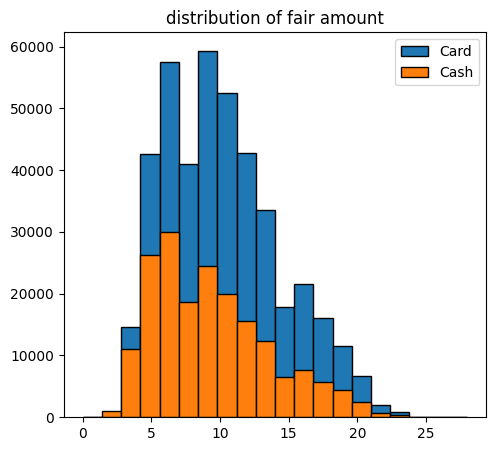

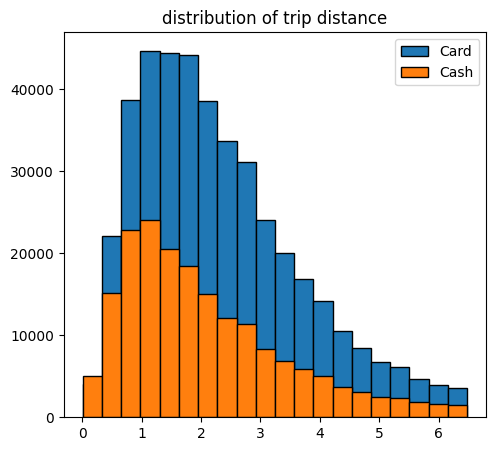

In [135]:
plt.figure(figsize = (12,5))
plt.subplot(1,2,1)
plt.title('distribution of fair amount')
plt.hist(df['fare_amount'][df['payment_type']=='Card'],bins=20,edgecolor='k', label='Card')
plt.hist(df['fare_amount'][df['payment_type']=='Cash'],bins=20,edgecolor='k', label='Cash')
plt.legend()
plt

plt.figure(figsize = (12,5))
plt.subplot(1,2,1)
plt.title('distribution of trip distance')
plt.hist(df['trip_distance'][df['payment_type']=='Card'],bins=20,edgecolor='k', label='Card')
plt.hist(df['trip_distance'][df['payment_type']=='Cash'],bins=20,edgecolor='k', label='Cash')
plt.legend()
plt

In [136]:
df.groupby('payment_type').agg({'fare_amount':['mean','std'],'trip_distance':['mean','std']})

fare_amount           trip_distance          
                    mean       std          mean       std
payment_type                                              
Card           10.263166  4.182351      2.319437  1.348577
Cash            9.461472  4.226123      2.067018  1.364792

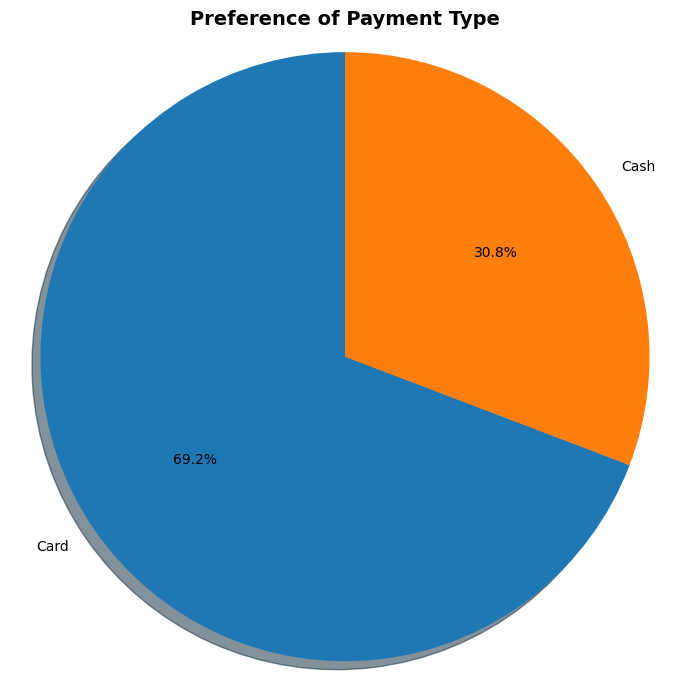

In [137]:
counts = df['payment_type'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=90,
    shadow=True
)

plt.title('Preference of Payment Type', fontsize=14, fontweight='bold')
plt.axis('equal')  # keeps the pie circular
plt.tight_layout()
plt.show()

In [138]:
passenger_count = df.groupby(['payment_type','passenger_count'])[['passenger_count']].count()
passenger_count.rename(columns = {'passenger_count':'count'},inplace = True)
passenger_count.reset_index(inplace = True)
passenger_count

,payment_type,passenger_count,count
0,Card,1,284287
1,Card,2,79466
2,Card,3,26878
3,Card,4,10404
4,Card,5,19612
5,Cash,1,134638
6,Cash,2,32224
7,Cash,3,9541
8,Cash,4,3680
9,Cash,5,7113


In [139]:
passenger_count['perc']=(passenger_count['count']/passenger_count['count'].sum())*100

In [140]:
passenger_count

,payment_type,passenger_count,count,perc
0,Card,1,284287,46.769807
1,Card,2,79466,13.073442
2,Card,3,26878,4.421866
3,Card,4,10404,1.711626
4,Card,5,19612,3.226491
5,Cash,1,134638,22.150128
6,Cash,2,32224,5.301369
7,Cash,3,9541,1.569649
8,Cash,4,3680,0.605419
9,Cash,5,7113,1.170203


In [141]:
df2 = pd.DataFrame(columns =['payment_type',1,2,3,4,5])
df2['payment_type']=['Card','Cash']
df2.iloc[0,1:] = passenger_count.iloc[0:5,-1]
df2.iloc[1,1:] = passenger_count.iloc[5:,-1]
df2

,payment_type,1,2,3,4,5
0,Card,46.769807,13.073442,4.421866,1.711626,3.226491
1,Cash,22.150128,5.301369,1.569649,0.605419,1.170203


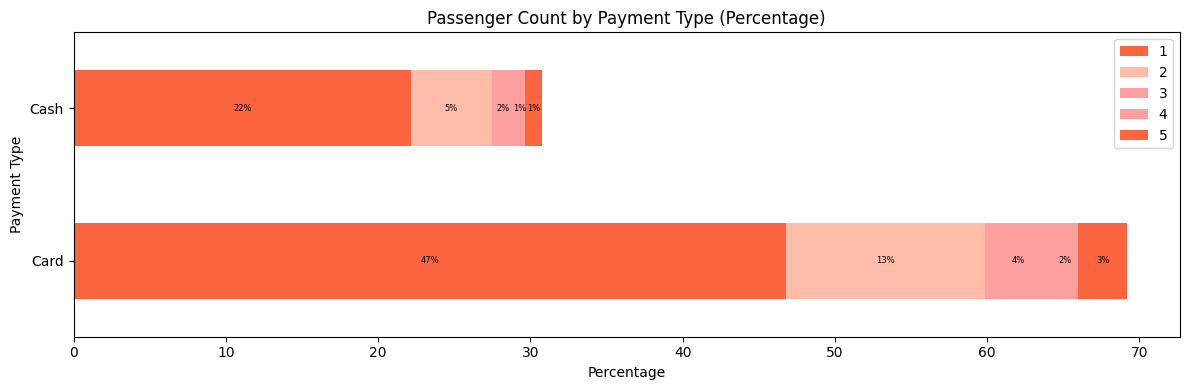

In [142]:
ax = df2.set_index('payment_type').plot(
    kind='barh',
    stacked=True,
    figsize=(12, 4),
    color=['#FA643F', '#FFBCAB', '#FD9F9F', '#FD9F9F']
)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        label_type='center',
        fmt='%.0f%%',
        fontsize=6,
        color='black'
    )

plt.xlabel('Percentage')
plt.ylabel('Payment Type')
plt.title('Passenger Count by Payment Type (Percentage)')
plt.tight_layout()
plt.show()

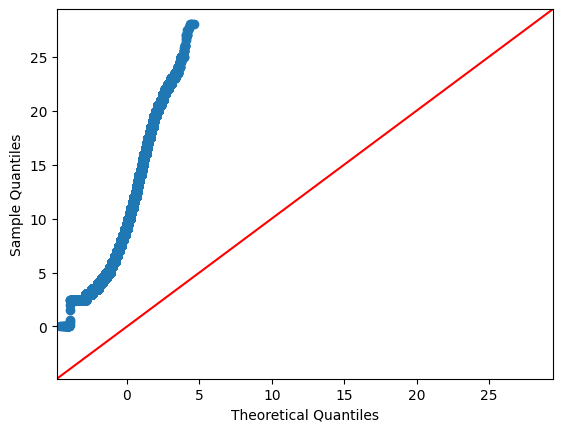

In [143]:
sm.qqplot(df['fare_amount'],line = '45')
plt.show()


hypthesis testing
null hypthesis - there is no difference in average fair between customers who pay through credit card and customers who pay through cash

alternative hypothesis - there is difference in average fair between customers who pay through credit card and customers who pay through cash

In [144]:
cashsample = df[df['payment_type']=='Cash']['fare_amount']
cardsample = df[df['payment_type']=='Card']['fare_amount']
t_stats, p_value = st.ttest_ind(a=cashsample,b=cardsample,equal_var=False)
print('t_stats:',t_stats)
print('p_value:',p_value )

t_stats: -68.49524782204689
p_value: 0.0


solution :

With such a low p-value, we reject the null hypothesis. This means that there is a significant difference in the average fare between customers who pay through credit card and customers who pay through cash.